In [13]:
# Imports
import torch
import torch.nn as nn 
from torch.nn import MSELoss, L1Loss, BCELoss, CrossEntropyLoss
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random 

SEED=42
def seed_everything(seed):
    random.seed(seed) # set seed for random
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False
seed_everything(SEED)


# Fits an exponential curve f(x) = ae^(bx) using SSE loss
# (x1,y1).         ln y = bx+ln a --> t1=b, t2= ln a,  y'=ln y
#         [x1, 1][t1]= [y1]
#         [x2, 1][t2]  [y2]
#         [x3, 1]
def fit_exp(points: np.ndarray):
    # Put into form
    one = np.ones( (points.shape[0],1) )
    X =  points[:,0].reshape(-1,1)
    X = np.concat([X,one] , axis=1)
    y= np.log(points[:,1]).reshape(-1,1)

    t = np.linalg.inv(X.T @ X) @ X.T @ y 
    b = t[0][0]
    a = np.exp(t[1][0])
    return (a,b)


# Assume y is in float form so we need to round it first.
def get_accuracy(_pred: np.ndarray, _y: np.ndarray):
    pred = (_pred > 0.5).astype(int)
    y = _y.astype(int)
    correct = (pred == y).sum()
    total =  y.shape[0]
    return correct / total


def output_test_results(model, X_test, y_test):
    pred_float = model.forward(X_test).detach()
    # print("y_test=", y_test.shape,  y_test)
    # print("pred=", pred_float.shape, pred_float)

    bceloss_func = nn.BCELoss()
    bceloss = bceloss_func(pred_float, y_test)

    pred_float = pred_float.numpy()
    acc = get_accuracy(pred_float, y_test.numpy())


    print("-----------------------")
    print("Test Accuracy = ", acc )
    print("Test BCEloss = ", bceloss)
    print("-----------------------")


loss1= 0.3530179560184479
after------------------------------
loss2= 0.033119477331638336


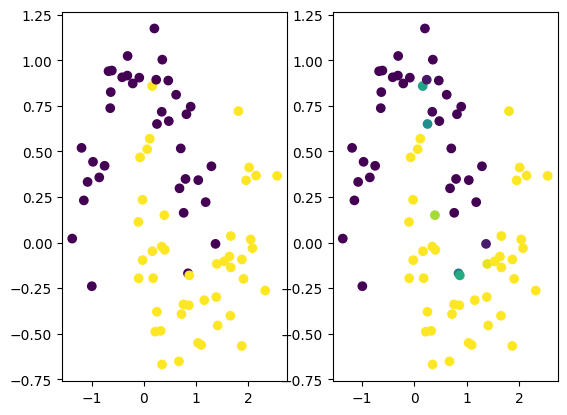

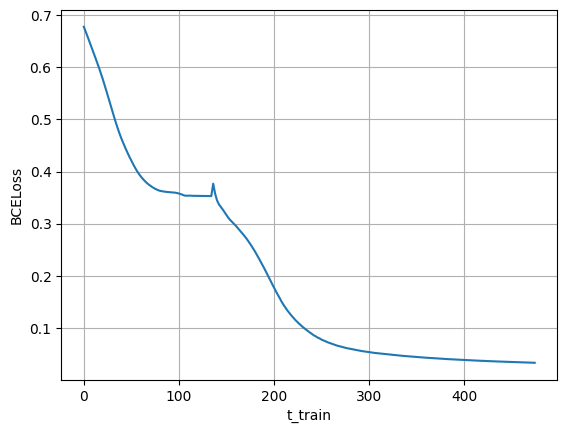

In [14]:
seed_everything(SEED)

# DEFAULT:  n_samples=100, noise=0.2, random_state=42   : capacity=50

# Generate dataset
X, y = make_moons(n_samples=100, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Convert to pytorch tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


class MLP(nn.Module):
    # linear_idx = The indices that linear layers are located at.
    def __init__(self, in_dim, out_dim, hidden=(2,2,2), activation="relu", dropout=0.0):
        super().__init__()
        # 1. Choose the activation function
        act_fn_map = {"relu": nn.ReLU, "sigmoid": nn.Sigmoid, "tanh": nn.Tanh}
        act_fn = act_fn_map[activation]

        # 2. Create the layers
        layers = []; linear_idx = []
        i=0 # current layer index
        prev_layer_size = in_dim 
        for curr_layer_size in hidden: 
            fci = nn.Linear(prev_layer_size, curr_layer_size) # fully connected linear layer
            acti = act_fn()
            linear_idx.append(i);  layers.append(fci);  i+=1 # Add linear layer
            layers.append(acti); i+=1 # Add activation layer
            prev_layer_size = curr_layer_size 

        linear_idx.append(i); fci = nn.Linear(prev_layer_size,  out_dim); i+=1
        acti = nn.Sigmoid()
        layers.append(fci); layers.append(acti)

        self.network = nn.Sequential(*layers)
        self.linear_idx = linear_idx

        # Measuring the loss
        self.loss_history = []# The complete loss history of the network, including losses from parent networks (big and expensive so is opt-in)
        self.loss_store_rate = 2 # The rate at which we store the loss, used so we don't end up storing too much
        self.final_loss_history = [] # just the final losses from the network history
        self.heuristics = []

    def forward(self, x):
        y_hat = self.network(x)
        return y_hat 
    
    # cfg:  {max_epoch, 
    #        loss = the loss function used ("MSE" or "MAE" or "BCE"),
    #        lr = initial learning rate
    #        patience = 20  , max no.iterations it is allowed to not improve for}
    def train_model(self, cfg, X_tr, y_tr, store_loss=True):
        max_epoch = cfg["max_epoch"]

        criterion = MSELoss()
        if cfg["criterion"] == "MSE": criterion = MSELoss()
        elif cfg["criterion"] == "MAE": criterion = L1Loss()
        elif cfg["criterion"] == "BCE": criterion= BCELoss()

        patience = cfg["patience"] # Max number of epochs for which training loss can't improve

        optimizer = torch.optim.Adam(self.parameters(), lr=cfg["lr"])
        
        epoch =0 
        final_loss = 1_000_000
        prev_loss = np.inf; nconsecutive_bad_epochs = 0 
        while epoch < max_epoch and nconsecutive_bad_epochs < patience:
            self.train()
            epoch += 1
            curr_loss = 0.0 

            #------------------------
            # prediction = torch.flatten( self(X_tr) )
            prediction = self(X_tr)
            loss = criterion(prediction, y_tr)
            loss.backward()
            curr_loss += float(loss)
            final_loss = curr_loss

            #------------------------

            optimizer.step()
            optimizer.zero_grad() # Reset gradients so it doesn't accumulate
            
            # if store_loss:
            if store_loss and epoch % self.loss_store_rate == 0: # every 10 epochs, store the loss
                self.loss_history.append(curr_loss)

            nconsecutive_bad_epochs = nconsecutive_bad_epochs+1 if prev_loss-curr_loss < 0.0001 else 0

            # if nconsecutive_bad_epochs >= patience:
            #     print("early stop at epoch=", epoch)

            prev_loss = curr_loss
        self.final_loss_history.append(final_loss)
        
        return final_loss 

    #* Growing utilities *#
    # Adds a new unit to the end of the specified layer, with weight=1 for incoming weights
    def add_unit(self, layer):
        # 1) Add weights & bias going into the new neuron
        # print("prev")
        linear_layer = self.linear_idx[layer]
        # print("layer before=", self.network[linear_layer])

        prev_weights = self.network[linear_layer].weight[:]
        prev_bias    = self.network[linear_layer].bias[:]

        assert(layer+1 < len(self.linear_idx)) # An attempt to add a new output - may want it but strange
        

        # new_in_weights = torch.zeros(1,prev_weights.shape[1]) # torch.tensor([[1,2,3,4,5]])
        new_in_weights =  torch.from_numpy( np.random.normal(0., 1, size=(1, prev_weights.shape[1])) ) 

        new_bias = torch.tensor([0.]) #torch.tensor([69.])

        result_w = torch.concatenate((prev_weights, new_in_weights), axis=0)
        # print("weights_before=", prev_weights, prev_weights.shape) # (out_weights, in_weights)
        # print("-->", result_w)
        result_b = torch.concatenate( (prev_bias, new_bias), axis=0 )
        # print("bias before=", prev_bias)
        # print("-->", result_b)

        # Add the new weights to the network
        # a) Create a new nn.Linear with the new size
        with torch.no_grad():
            in_dim = prev_weights.shape[1]; out_dim  = prev_weights.shape[0]  # old Dimensions
            l = nn.Linear(in_dim, out_dim+1)
            l.weight[:] = result_w 
            l.bias[:] = result_b 
            self.network[linear_layer] = l 

        # 2) Add weights and bias going out of the new neuron
        # next_layer = self.linear_idx[layer+1]
        if layer+1 < len(self.linear_idx):
            linear_layer =self.linear_idx[layer+1]
            next_weights = self.network[linear_layer].weight[:]
            next_bias = self.network[linear_layer].bias[:] # Idk if bias changes
            in_dim = next_weights.shape[1]; out_dim = next_weights.shape[0]

            # Make the new weights via a random gaussian distribution
            out_weights = torch.from_numpy( np.random.normal(size=(out_dim,1)) ) 

            # Add the column
            with torch.no_grad():
                result_w = torch.concatenate( (next_weights, out_weights), axis=1)
                l = nn.Linear(in_dim+1, out_dim)
                l.weight[:] = result_w
                l.bias[:] = next_bias # bias is unchanged
                self.network[linear_layer] = l 

        

    # eg layers=[1,2,1] adds 2 nodes to layer 1 and 1 node to layer 2.
    def add_units(self, layers: np.ndarray):
        for layer_num in layers:
            # print("layer_num=", layer_num)
            self.add_unit(layer_num)



    # Calculates the f-score of the MLP by modelling a curve from the recent previous losses
    def get_fscore_method1(self, max_iterations, n_samples=4):
        # _losses= [3,5, 2,1,1] 
        _losses = self.final_loss_history
        num_samples = n_samples # take the 4 most recent samples to model it
        losses = np.array(_losses)
        samples = losses[-num_samples: ]

        # Get into format [ [x,y], [x,y] ]
        x = np.arange(len(losses))[-num_samples: ]
        points = np.column_stack( (x,samples) )

        a,b = fit_exp(points)
        #-------------------- Method1: When it has converged
        #------------------- Method2: predict its score after the max no.iterations (simpler)
        if max_iterations==None:
            current_x = x[x.shape[0]-1];  future_x = current_x + 5 # Alternatively maybe just use what its value will be after some turns
        else: 
            future_x = max_iterations

        f_score = a*np.exp(b*future_x)
        return float(f_score)
    
    # Calculates the f-score of the MLP by modelling a curve from the recent previous losses
    def get_fscore_method2(self, n_samples=4):
        # _losses= [3,5, 2,1,1] 
        _losses = self.final_loss_history
        num_samples = n_samples # take the 4 most recent samples to model it
        losses = np.array(_losses)
        samples = losses[-num_samples: ]

        # Get into format [ [x,y], [x,y] ]
        x = np.arange(len(losses))[-num_samples: ]
        points = np.column_stack( (x,samples) )

        epsilon = -0.01
        a,b = fit_exp(points)
        #-------------------- Method1: When it has converged
        future_x = np.log(epsilon/(a*b)) / b
        current_x = x[x.shape[0]-1];  
        
        dydx= a*b*np.exp(b*current_x) # gradient at current position
        
        if dydx > 0 or np.abs(dydx) < -epsilon: # It is ascending/ gradient very small so will give weird results; just take some future point
            future_x = current_x + 10 # Alternatively maybe just use what its value will be after some turns
            f_score = a*np.exp(b*future_x)
        else:
            f_score = epsilon / b
        # print("a=", a, "b=", b, "->", f_score)

        return float(f_score)

    

    # def freeze_weights()
    #--- Visualisation -----
    def plot_loss(self):
        plt.xlabel("t_train"); plt.ylabel("BCELoss")
        plt.grid(True)
        losses =self.loss_history
        plt.plot(range(0, len(losses)*self.loss_store_rate, self.loss_store_rate), losses)
        plt.show()
    def plot_final_loss(self):
        losses =self.final_loss_history
        plt.grid(True)
        plt.xlabel("t"); plt.ylabel("BCELoss")
        plt.plot(range(0, len(losses)), losses)
        plt.show()

    def plot_all(self):
        fig, ax = plt.subplots(1,2, constrained_layout=True)
        losses =self.loss_history

        ax[0].set(xlabel="t_train", ylabel="BCELoss")
        ax[0].grid(True)
        ax[0].plot(range(0, len(losses)*self.loss_store_rate, self.loss_store_rate), losses)

        losses = self.final_loss_history
        ax[1].set(xlabel="t", ylabel="BCELoss")
        ax[1].grid(True)
        # ax[0,1].xlabel("t"); plt.ylabel("BCELoss")
        ax[1].plot(range(0, len(losses)), losses)
        plt.show()


        
    def print_weights(self):   
        i =0
        for layer in self.linear_idx:
            print("Layer", i); i+=1
            print("w=", self.network[layer].weight[:])
            print("b=", self.network[layer].bias[:])
    
    def randomize_weights(self):
        with torch.no_grad():
            for layer in self.linear_idx:
                self.network[layer].weight[:] = torch.from_numpy( np.random.normal(0., 1, size=self.network[layer].weight[:].shape)  ) 
                self.network[layer].bias[:] = torch.from_numpy( np.random.normal(0., 1., size=self.network[layer].bias[:].shape ) )

        


def test():
    # Test it works
    model_test = MLP(in_dim=2, hidden=(2,2),out_dim=1, dropout=0.0)

    with torch.no_grad():
        print(model_test.network[0].weight)
        # Layer1 
        model_test.network[0].weight[:] = torch.tensor([ [5.,4.], [3., 1.]])
        model_test.network[0].bias[:] = torch.tensor([0.,0.])

        # Layer2 
        model_test.network[2*1].weight[:] = torch.tensor(  [[3., 5.], [3., 1.]] )
        model_test.network[2*1].bias[:] = torch.tensor( [1., 0.])

        # Layer3
        model_test.network[2*2].weight[:] = torch.tensor( [ [2., 4.] ] )
        model_test.network[2*2].bias[:] = torch.tensor( [0.])

        result = model_test(torch.tensor([1., 1.]))

        


        # print(model_test)
        # print(result)  # Should be 220
# test()

cfg = {"max_epoch": 500, "criterion": "BCE", "lr": 0.01, "patience": 20}
model = MLP(in_dim=2, hidden=(2,3), out_dim=1)  # hidden=(50,2)
# print("model=", model)

loss1= model.train_model(cfg, X_train, y_train)
print("loss1=", loss1)
# print(model.network)
# model.print_weights()

# pred = model.forward(X_train).detach().numpy()
# pred = (pred > 0.5).astype(int) # Convert to either 1 or 0

# print("linear_idx=", model.linear_idx)
print("after------------------------------")
model.add_unit(0); model.add_unit(0);  model.add_unit(0); model.add_unit(1)
model.add_unit(0); model.add_unit(0);  model.add_unit(0);
model.add_unit(0); model.add_unit(0);  model.add_unit(0);
# model.print_weights()

loss2 = model.train_model(cfg, X_train, y_train)
print("loss2=", loss2)






# model.print_weights()
# model.print_weights()
# print("out=", model.forward(torch.tensor([1., 1.])) )
# pred = model.forward(X_train).detach().numpy()

def test_make_moons(model, X_train, y_train):
    pred = model.forward(X_train).detach().numpy()
    
    fig, ax = plt.subplots(1,2, constrained_layout=False)

    # Visualize make_moons test
    ax[0].scatter(X_train[:,0],X_train[:,1], c=y_train, cmap="viridis") # c is color
    ax[1].scatter(X_train[:,0], X_train[:,1], c=pred, cmap="viridis")
    plt.show()
    return pred

test_make_moons(model, X_train, y_train)

model.plot_loss()


# import copy  
# model2 = copy.deepcopy(model)
# print(model.loss_history)




i= 0
best f-score= 1.0 best loss= 1.0
n bad iterations= 0

i= 1
best f-score= 0.009431167674484334 best loss= 0.23843689262866974
n bad iterations= 0

i= 2
best f-score= 0.009431167674484334 best loss= 0.23843689262866974
n bad iterations= 1

i= 3
best f-score= 0.009431167674484334 best loss= 0.23843689262866974
n bad iterations= 2

i= 4
best f-score= 0.009431167674484334 best loss= 0.23843689262866974
n bad iterations= 3

i= 5
best f-score= 0.009431167674484334 best loss= 0.23843689262866974
n bad iterations= 4

i= 6
best f-score= 1.3873831591004664e-06 best loss= 0.0124479616060853
n bad iterations= 0

i= 7
best f-score= 1.3873831591004664e-06 best loss= 0.0124479616060853
n bad iterations= 1

i= 8
best f-score= 1.3873831591004664e-06 best loss= 0.0124479616060853
n bad iterations= 2

i= 9
best f-score= 1.3873831591004664e-06 best loss= 0.0124479616060853
n bad iterations= 3

i= 10
best f-score= 1.3873831591004664e-06 best loss= 0.0124479616060853
n bad iterations= 4


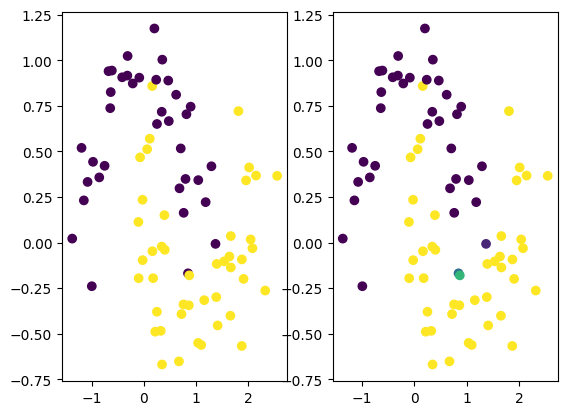

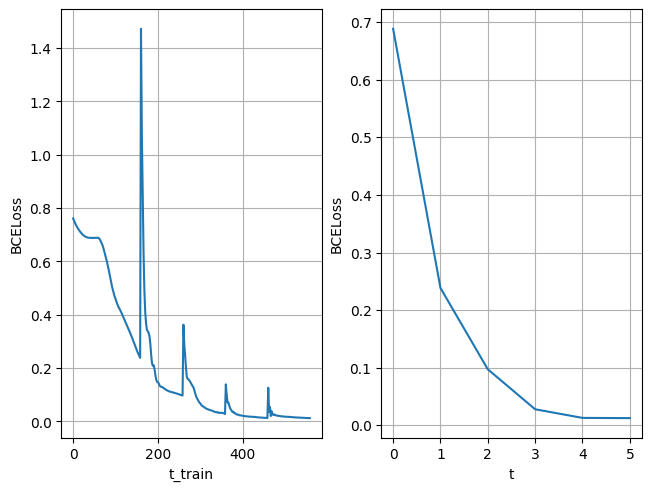

Final loss= 0.0124479616060853
loss history= [0.7612320184707642, 0.7536963224411011, 0.7458100318908691, 0.7387439012527466, 0.7325871586799622, 0.7271050214767456, 0.7219430804252625, 0.7170839905738831, 0.712557315826416, 0.7083901762962341, 0.7046061754226685, 0.7012243866920471, 0.698257565498352, 0.6957113742828369, 0.693583071231842, 0.6918600797653198, 0.6905199885368347, 0.6895300149917603, 0.6888483762741089, 0.6884255409240723, 0.6882075667381287, 0.6881395578384399, 0.688168466091156, 0.6882486343383789, 0.6883428692817688, 0.6884251832962036, 0.688480019569397, 0.6885017156600952, 0.6884921193122864, 0.6884576082229614, 0.6882503032684326, 0.6845027804374695, 0.6797015070915222, 0.6732431650161743, 0.6659029722213745, 0.6570901274681091, 0.6463950872421265, 0.6334807276725769, 0.6202877759933472, 0.6093395948410034, 0.5970746278762817, 0.5827841758728027, 0.5678693056106567, 0.5517584681510925, 0.5347099900245667, 0.5181258916854858, 0.5035957098007202, 0.49101996421813965

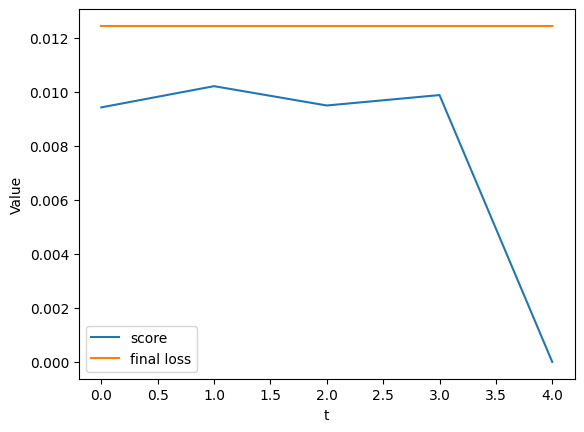

In [ ]:
import copy
import heapq

seed_everything(SEED)



def count_params(model):
    # Count parameters (ignoring biases)
    nonzero_weights = 0 
    total_weights = 0
    for module in model.modules():
        if hasattr(module, 'weight'):
            w = module.weight  # this is weight_orig * weight_mask
            nonzero_weights += (w != 0).sum().item()
            total_weights += w.numel()

    print("~~~~~~~~~~~~~~")
    print("total_weights=", total_weights)
    print("nonzero_weights=", nonzero_weights)
    print("~~~~~~~~~~~~~~")



# Returns the best layers to add nodes to
#TODO: At the moment it uses a simple and kinda bad method of choosing node with highest magnitudes, could improve with a more thought out idea eg one where adding a neuron above would maximize it.
#TODO:  -  Also I'm pretty sure this method will love to expand 
# b = branch factor
# max_growth = the maximum number of nodes a branch is able to add in a single iteration (named 'eta' in the paper)
# p_mg = the probability of getting the maximum growth from an exponential distribution (clipped)
def get_expand_layers(model:MLP, b, max_growth, p_mg):
    # 1) Get weights with highest magnitude
    vertex_importances = []
    llayers = model.linear_idx[0: len(model.linear_idx)-1]; # We should avoid adding to the output layer

    l=0
    for layer in llayers:
        w_l = model.network[layer].weight # Weights for this layer
        layer_importance = torch.max( torch.flatten( torch.abs(w_l) ) ) # the score of the layer is the absolute value of the largest weight
        vertex_importances.append( [float(layer_importance), l] )
        l+=1

    # Probability distribution that favours layers with higher importance
    vimp = np.array(vertex_importances) # vertex importances
    verts = vimp[:,1].astype(int); p = vimp[:,0] # lower importance = higher probability
    softmax = p / np.sum(p) ; #np.exp(temperature*p) / np.sum(np.exp(temperature*p))

    # 2) Choose the number of nodes to add for each branch, over time it is more likely to add fewer nodes
    # If lambda = -1/c  ln(p), then the output will be >= c with probability at least p.
    # We can set it outputs it is >=5 as a certainty at the start, but this chance decreases over time
    c= max_growth
    beta = - c/ np.log(p_mg)
    n_new = np.round( np.clip(np.random.exponential(scale=beta, size=20), a_min=1, a_max=c) )
    # Choose the layers for each branch
    layers =  [np.random.choice(verts, size=int(n_new[i]), p=softmax ) for i in range(b)] # [  branch1: [layer1, layer1, layer2]    ]
    return layers


# TODO: max_params = the maximum number of parameters being trained at a given time. 
# - to prevent memory useage exploding too much
# We'll do max_nodes instead actually for now cos thats easier and there's also implications on whether the former would prioritise smaller or bigger models that I don't want to think about rn
# stochastic beam search
# PARAMS
# capacity = the maximum number of nodes being expanded in the search tree
# k = the no.child states considered, k=b by default
# b = the branch factor.
# freeze = Will freeze the old weights and only train the new ones to speed up training.
# cfg = the configurations for how each node is trained.
def beam_train(model: MLP, cfg, X_tr, y_tr,  max_iterations=10, patience=5, b=2, k=2, freeze=False, max_growth=5, capacity=50, random_initialization=False, verbose=True):
    k = max(b, k)

    # 1) Copy the model
    model0 = copy.deepcopy(model)
    model0.train_model(cfg, X_tr, y_tr) # Train the current network
 
    frontier = []
    heapq.heappush(frontier, (1.0, model0)) # Use a heap for the priority queue

    # print("queue=", frontier)
    nconsecutive_bad_iter = 0; epsilon = 0.0001 # Convergence condition
    best_model = (1.0, model0); best_loss = 1.0



    n_iterations = max_iterations
    i=0
    while len(frontier) > 0 and i<n_iterations and nconsecutive_bad_iter < patience:
        if verbose:
            print("\ni=", i)
            print("best f-score=", best_model[0], "best loss=", best_loss)
            # print("frontier=", [x[0] for x in frontier])
            print("n bad iterations=", nconsecutive_bad_iter)

        #?---------------------------------------------------------- ?#
        #? Memory killer - Keep dropping bad states until we're at the required capacity
        frontier.sort(key= lambda x: x[0], reverse=True)  
        frontier = frontier[:capacity] # Remove bad elements
        heapq.heapify(frontier)
        #?---------------------------------------------------------- ?#

        curr_fscore, current = heapq.heappop(frontier) # A trained network
        next_layers = get_expand_layers(current, k, max_growth, 0.6)


        #? Freeze weights ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # for param in current.
        current : MLP = current
        if freeze:
            current.network.requires_grad_(False) # Freeze all the old weights
        #? ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


        # 2) Create the child nodes
        # prev_fscore= best_model[0]
        candidates = []
        prev_best_loss =best_loss
        for l in next_layers:
            #TODO: Here u should compare continuing from current initialization, or from random initialization
            #--------------------------------------------
            # Start from current initialization approach
            #--------------------------------------------
            new_model = copy.deepcopy(current)

            if random_initialization:
                new_model.randomize_weights()

            # Add the new nodes
            new_model.add_units(l)
            

            # Unfreeze the new weights
            # Train the model to get its f-score. f=current_loss + estimate = g + estimate
            gscore = new_model.train_model(cfg, X_tr, y_tr)

            #?---------- Calculate the f-score ----------------
            # # a) Model a curve from the recent previous losses
            #------------------------------------ 2 types
            # fscore = gscore
            fscore = new_model.get_fscore_method2(n_iterations) #n_iterations)  # get_fscore(new_model, max_iterations) 
            new_model.heuristics.append(fscore) # Store the fscore
            #-----------------------------------
            # print("loss history=", new_model.final_loss_history)
            #?-----------------------------------------------
            
            # print(l, "predicted f-score=", fscore)
            # frontier.append( new_model)
            candidates.append((fscore, new_model ))
            # heapq.heappush(frontier, (fscore, new_model))

            # Keep track of the current best model
            if fscore < best_model[0]:
                best_model = (fscore, new_model)
                best_loss = gscore
        
        candidates = sorted(candidates, key= lambda x: x[0])[:b] # only take the b-best candidates
        for (fscore,new_model) in candidates:
            heapq.heappush(frontier, (fscore, new_model))




        # nconsecutive_bad_iter = nconsecutive_bad_iter+1 if prev_fscore-best_model[0] < epsilon else 0 # convergence
        nconsecutive_bad_iter = nconsecutive_bad_iter+1 if prev_best_loss - best_loss < epsilon else 0 # convergence
        # print("prevloss - curr loss = ", prev_best_loss - best_loss )
        i += 1

    # Return the best model
    _, best = best_model
    return best, best_loss



cfg = {"max_epoch": 100, "criterion": "BCE", "lr": 0.01, "patience": 20}
model = MLP(in_dim=2, hidden=(2,3,2,2), out_dim=1)  # hidden=(50,2)
# result = beam_train(model, max_nodes=20)

# loss1= model.train_model(cfg, X_train, y_train)



#--------------
model_trained, final_loss= beam_train(model, cfg, X_train, y_train, b=4, capacity=50, max_iterations=20)
test_make_moons(model_trained, X_train, y_train)
model_trained.plot_all()
# print("Dimensions:")
# print(model_trained)

pred = model.forward(X_train).detach()


print("Final loss=", final_loss)
print("loss history=", model_trained.loss_history)

# model_trained.print_weights()

print(model_trained)
# model_trained.plot_loss()
# model_trained.plot_final_loss()
print("finall losses=", model_trained.final_loss_history)

output_test_results(model_trained, X_test, y_test)

count_params(model_trained)




# Plot heuristics
def plot_heuristics(model: MLP):
    plt.xlabel("t"); plt.ylabel("Value") # Plot of th predicted final loss vs actual final loss
    scores = np.array(model.heuristics)
    final_loss = model.final_loss_history[-1] # last entry, gives the "true final loss"
    # print("scores=", scores )
    # print("final losses=", [final_loss for _ in range(0,len(scores))]  )

    plt.plot(range(0, len(scores)), scores, label="score")
    plt.plot(range(0, len(scores)), [final_loss for _ in range(0,len(scores))], label="final loss")
    plt.legend()
    
    plt.show()

plot_heuristics(model_trained)
            





This code tests how it works when you freeze the previous weights beforehand and only train the newly added ones.

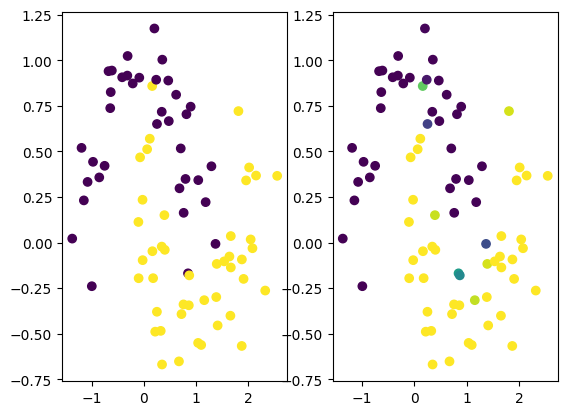

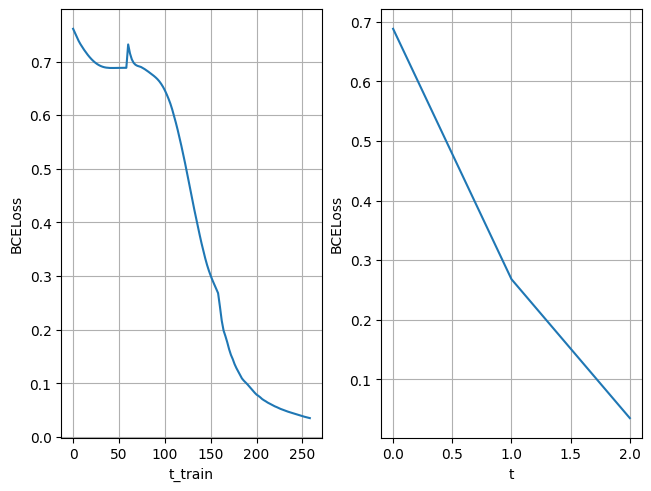

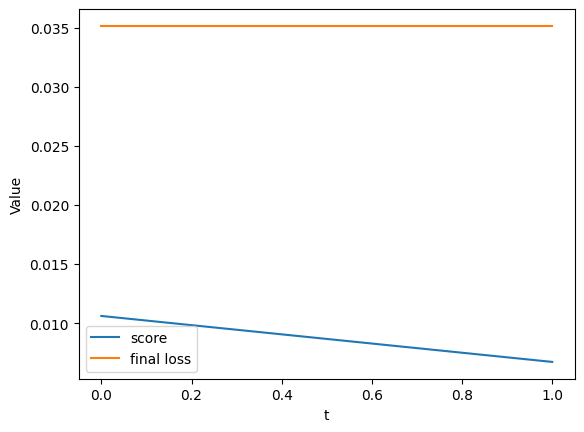

-----------------------
Test Accuracy =  0.95
Test BCEloss =  tensor(0.3324)
-----------------------
~~~~~~~~~~~~~~
total= 72
total_weights= 72
~~~~~~~~~~~~~~


In [16]:
seed_everything(SEED)

RUN_FREEZE =True
if RUN_FREEZE:
    cfg = {"max_epoch": 100, "criterion": "BCE", "lr": 0.01, "patience": 20}
    model = MLP(in_dim=2, hidden=(2,3,2,2), out_dim=1) 

    model_trained, final_loss= beam_train(model, cfg, X_train, y_train, b=4, capacity=50, max_iterations=20, freeze=True, verbose=False) 
    
    
    test_make_moons(model_trained, X_train, y_train)
    model_trained.plot_all();plot_heuristics(model_trained)

    output_test_results(model_trained, X_test, y_test)
    
    count_params(model_trained)


This code tests how it works when you prune it

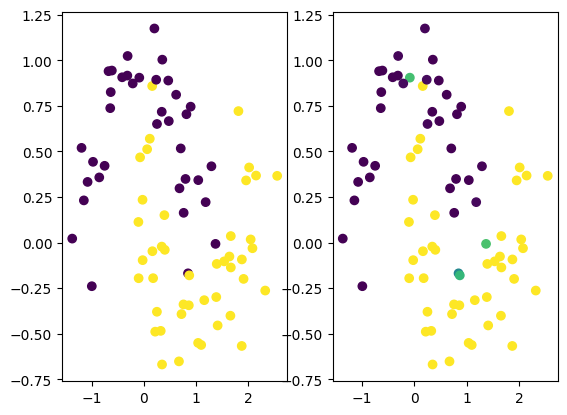

pred= torch.Size([80, 1])
y_train= torch.Size([80, 1])
model= MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=9, bias=True)
    (1): ReLU()
    (2): Linear(in_features=9, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=9, bias=True)
    (5): ReLU()
    (6): Linear(in_features=9, out_features=5, bias=True)
    (7): ReLU()
    (8): Linear(in_features=5, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
error= 0.045326750725507736


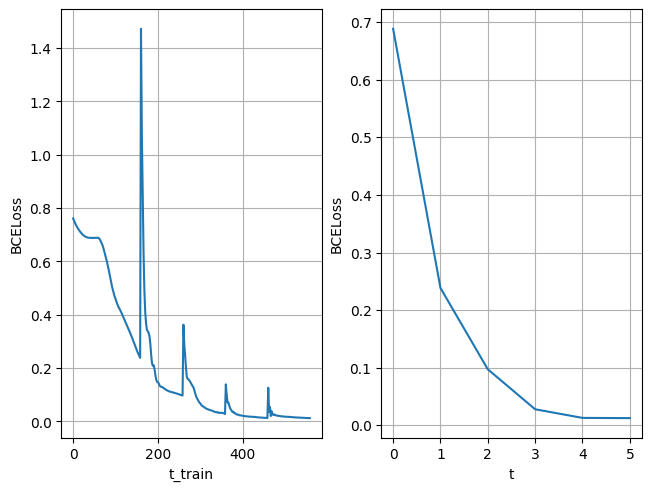

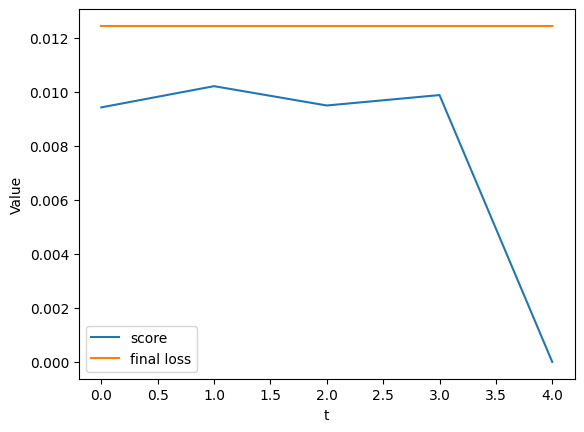

-----------------------
Test Accuracy =  0.9
Test BCEloss =  tensor(0.7297)
-----------------------
~~~~~~~~~~~~~~
total= 176
total_weights= 141
~~~~~~~~~~~~~~


In [17]:
import torch.nn.utils.prune as prune
seed_everything(SEED)

RUN_PRUNE = True
if RUN_PRUNE:
    cfg = {"max_epoch": 100, "criterion": "BCE", "lr": 0.01, "patience": 20}
    model = MLP(in_dim=2, hidden=(2,3,2,2), out_dim=1) 
    model_trained, final_loss= beam_train(model, cfg, X_train, y_train, b=4, capacity=50, max_iterations=20, verbose=False)

    # for layer in model.network. 
    prune_layers = [(model_trained.network[l], 'weight') for l in model_trained.linear_idx]
    # layers = model.linear_idx
    prune.global_unstructured(prune_layers, pruning_method=prune.L1Unstructured, amount=0.2) # Prune it


    # print(prune_layers)
    test_make_moons(model_trained, X_train, y_train)
    pred = model_trained.forward(X_train).detach()

    print("pred=", pred.shape)
    print("y_train=", y_train.shape)
    print("model=", model_trained)

    # loss =BCELoss()
    loss_function = nn.BCELoss()
    error = loss_function(pred, y_train)
    
    error = float(error)
    print("error=", error)


    model_trained.plot_all()
    plot_heuristics(model_trained)

    output_test_results(model_trained, X_test, y_test)
    
    count_params(model_trained)
    # prune.l1_unstructured(model, name="weight", amount=0.2)



This code tests if the 'semi lottery ticket hypothesis' is applicable for growing networks.


i= 0
best f-score= 1.0 best loss= 1.0
n bad iterations= 0

i= 1
best f-score= 0.013835860709940279 best loss= 0.33417314291000366
n bad iterations= 0

i= 2
best f-score= 0.013835860709940279 best loss= 0.33417314291000366
n bad iterations= 1

i= 3
best f-score= 0.013835860709940279 best loss= 0.33417314291000366
n bad iterations= 2

i= 4
best f-score= 0.013835860709940279 best loss= 0.33417314291000366
n bad iterations= 3

i= 5
best f-score= 0.013835860709940279 best loss= 0.33417314291000366
n bad iterations= 4

i= 6
best f-score= 0.013794818978033896 best loss= 0.06918303668498993
n bad iterations= 0

i= 7
best f-score= 0.013794818978033896 best loss= 0.06918303668498993
n bad iterations= 1

i= 8
best f-score= 0.013794818978033896 best loss= 0.06918303668498993
n bad iterations= 2

i= 9
best f-score= 0.013794818978033896 best loss= 0.06918303668498993
n bad iterations= 3

i= 10
best f-score= 0.013794818978033896 best loss= 0.06918303668498993
n bad iterations= 4
MLP(
  (network): Se

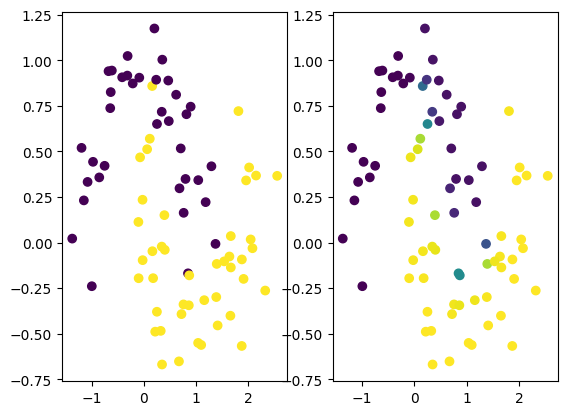

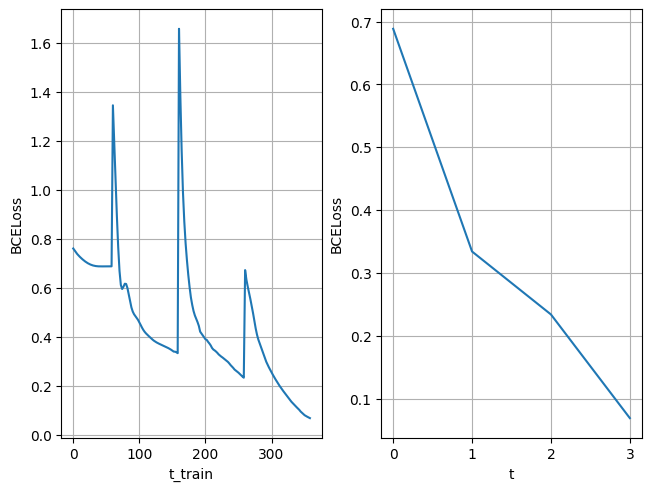

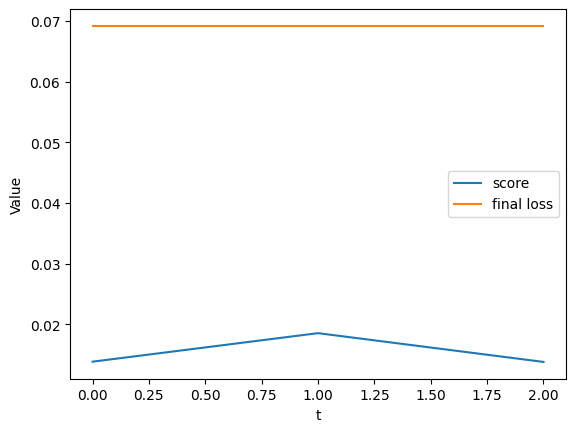

-----------------------
Test Accuracy =  0.95
Test BCEloss =  tensor(0.1144)
-----------------------
~~~~~~~~~~~~~~
total= 82
total_weights= 82
~~~~~~~~~~~~~~


In [18]:
import torch.nn.utils.prune as prune
seed_everything(SEED)

LOTTERY = True
if LOTTERY:
    cfg = {"max_epoch": 100, "criterion": "BCE", "lr": 0.01, "patience": 20}
    model = MLP(in_dim=2, hidden=(2,3,2,2), out_dim=1) 
    model_trained, final_loss= beam_train(model, cfg, X_train, y_train, b=4, capacity=50, max_iterations=20, random_initialization=True)

    print(model_trained)

    test_make_moons(model_trained, X_train, y_train)
    model_trained.plot_all()
    plot_heuristics(model_trained)


    output_test_results(model_trained, X_test, y_test)

    count_params(model_trained)
